MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)


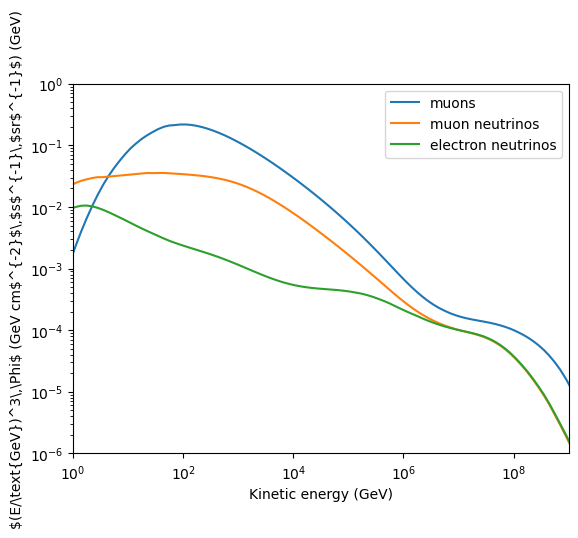

In [17]:
from MCEq.core import config, MCEqRun
import crflux.models as crf
# matplotlib used plotting. Not required to run the code.
import matplotlib.pyplot as plt


# Initalize MCEq by creating the user interface object MCEqRun
mceq = MCEqRun(

    # High-energy hadronic interaction model
    interaction_model='SIBYLL23D',

    # cosmic ray flux at the top of the atmosphere
    primary_model = (crf.HillasGaisser2012, 'H3a'),

    # zenith angle
    theta_deg = 15.
)

# Solve the equation system
mceq.solve()

# Obtain the result
# Multiply fluxes be E**mag to resolve the features of the steep spectrum
mag = 3
muon_flux = (mceq.get_solution('mu+', mag) +
             mceq.get_solution('mu-', mag))
numu_flux = (mceq.get_solution('numu', mag) +
             mceq.get_solution('antinumu', mag))
nue_flux = (mceq.get_solution('nue', mag) +
            mceq.get_solution('antinue', mag))

# The lines below are for plotting with matplotlib
plt.loglog(mceq.e_grid, muon_flux, label='muons')
plt.loglog(mceq.e_grid, numu_flux, label='muon neutrinos')
plt.loglog(mceq.e_grid, nue_flux, label='electron neutrinos')

plt.xlim(1., 1e9)
plt.xlabel('Kinetic energy (GeV)')
plt.ylim(1e-6, 1.)
plt.ylabel(r'$(E/\text{GeV})^3\,\Phi$ (GeV cm$^{-2}$\,$s$^{-1}\,$sr$^{-1}$) (GeV)')
plt.legend()
plt.show()